# Phase 2 - Mapping URL-Domain data to Countries

Trying to find out which countries published articles about the Winter Olympics.

Approach: 3 Level Domain Mapping
- Extract top-level domains from gdeltv2.gkg url field (e.g. .it, .de)
- Level 1: Map countries to top-level domains
- Level 2: Map global domains (.com, .org., .info) via sub-level mapping (min. 5 publications per domain)
- Level 3: Merge Level 1 and Level 2 mappings into "publisher_country_final"


In [1]:
import sys
!{sys.executable} -m pip install -q -U tldextract pyarrow db-dtypes pandas-gbq seaborn

In [3]:
import tldextract
from urllib.parse import urlparse
from pathlib import Path
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [5]:
# load query data from repo

data_path = Path("../data/gdelt_gkg_feb2026_relevance_ladder.parquet")
df = pd.read_parquet(data_path, engine="pyarrow")
# df["day"] = pd.to_datetime(df["day"])

df.shape

(30565, 17)

### Level 1: TLD-Country Mapping

In [6]:
# Helpfer Function to extract top-level domain
def extract_domain(url):
    try:
        return urlparse(url).netloc.lower()
    except:
        return None

df["domain"] = df["url"].apply(extract_domain)

df["tld"] = df["domain"].str.extract(r"\.([a-z]{2,})$")

df[["domain", "tld"]].head()

,domain,tld
0,www.zazoom.it,it
1,www.newsday.co.zw,zw
2,thesil.ca,ca
3,www.cinemablend.com,com
4,wdet.org,org


In [7]:
# Map domain to country
tld_country_map = {
    # Global / ambiguous
    "com": "Unknown / Global",
    "org": "Unknown / Global",
    "net": "Unknown / Global",
    "info": "Unknown / Global",
    "news": "Unknown / Global",
    "digital": "Unknown / Global",
    "network": "Unknown / Global",
    "asia": "Unknown / Global",
    "edu": "United States",   # mostly US
    "gov": "United States",   # mostly US
    
    # Europe
    "it": "Italy",
    "fr": "France",
    "es": "Spain",
    "de": "Germany",
    "nl": "Netherlands",
    "ro": "Romania",
    "lu": "Luxembourg",
    "ua": "Ukraine",
    "tr": "Turkey",
    "at": "Austria",
    "gr": "Greece",
    "sk": "Slovakia",
    "ie": "Ireland",
    "ch": "Switzerland",
    "be": "Belgium",
    "cz": "Czech Republic",
    "no": "Norway",
    "al": "Albania",
    "ru": "Russia",
    "hr": "Croatia",
    "rs": "Serbia",
    "pl": "Poland",
    "hu": "Hungary",
    "se": "Sweden",
    "dk": "Denmark",
    "bg": "Bulgaria",
    "mk": "North Macedonia",
    "ee": "Estonia",
    "ad": "Andorra",
    "lt": "Lithuania",
    "ba": "Bosnia and Herzegovina",
    "si": "Slovenia",
    "pt": "Portugal",
    "cy": "Cyprus",
    "sm": "San Marino",
    "scot": "Scotland",
    "uk": "United Kingdom",
    
    # North America
    "ca": "Canada",
    "mx": "Mexico",
    "us": "United States",
    "pr": "Puerto Rico",
    "hn": "Honduras",
    "do": "Dominican Republic",
    
    # South America
    "ar": "Argentina",
    "bo": "Bolivia",
    "uy": "Uruguay",
    "br": "Brazil",
    "cl": "Chile",
    "ec": "Ecuador",
    "py": "Paraguay",
    
    # Asia
    "jp": "Japan",
    "kr": "South Korea",
    "vn": "Vietnam",
    "pk": "Pakistan",
    "lk": "Sri Lanka",
    "in": "India",
    "hk": "Hong Kong",
    "ir": "Iran",
    "id": "Indonesia",
    "sg": "Singapore",
    "tw": "Taiwan",
    "am": "Armenia",
    "az": "Azerbaijan",
    "ge": "Georgia",
    "my": "Malaysia",
    "mo": "Macau",
    
    # Africa
    "ng": "Nigeria",
    "za": "South Africa",
    "gh": "Ghana",
    "ke": "Kenya",
    "mg": "Madagascar",
    "so": "Somalia",
    "af": "Afghanistan",
    
    # Oceania
    "au": "Australia",
    "nz": "New Zealand",
    "tv": "Tuvalu",   # media hosting
    "fm": "Micronesia",
    
    # Central America / Caribbean
    "cu": "Cuba",
    
    # Missing
    None: "Unknown / Global"
}

In [8]:
df["publisher_country_lvl1"] = df["tld"].map(tld_country_map)

In [9]:
df["publisher_country_lvl1"].value_counts().head(20)

publisher_country_lvl1
Unknown / Global    17853
Italy                7682
United Kingdom        648
France                590
Australia             276
Mexico                270
Canada                239
Spain                 184
Germany               145
Ireland               122
Malaysia               91
Romania                90
Greece                 62
Tuvalu                 61
Switzerland            59
Turkey                 54
Czech Republic         47
New Zealand            45
Pakistan               43
Slovakia               38
Name: count, dtype: int64

In [10]:
df["publisher_country_lvl1"].notna().mean()

0.9504335023719941

### Level 2: Sublevel TLD-Country Mapping

Mapping all sub-level domains with **5 or more publications**.

In [12]:
# Helper function for level 2 sub-domains
def base_domain(url):
    if not isinstance(url, str) or not url:
        return None
    ext = tldextract.extract(url)
    if not ext.domain or not ext.suffix:
        return None
    return f"{ext.domain}.{ext.suffix}".lower()

df["base_domain"] = df["url"].apply(base_domain)
df[["url","base_domain","tld","publisher_country_lvl1"]].head()

,url,base_domain,tld,publisher_country_lvl1
0,https://www.zazoom.it/2026-02-27/la-fiamma-par...,zazoom.it,it,Italy
1,https://www.newsday.co.zw/news/article/2000520...,newsday.co.zw,zw,NaN
2,https://thesil.ca/mcmaster-athletes-show-out-i...,thesil.ca,ca,Canada
3,https://www.cinemablend.com/television/is-alys...,cinemablend.com,com,Unknown / Global
4,https://wdet.org/2026/02/25/the-metro-team-usa...,wdet.org,org,Unknown / Global


In [13]:
# call level 2 domain mapping file
mapping_path = Path("../data/level_2_domain_country_mapping.csv")
domain_mapping = pd.read_csv(mapping_path)

# Convert to dictionary
if "publisher_country" in domain_mapping.columns:
    domain_country_map = dict(zip(domain_mapping["base_domain"], domain_mapping["publisher_country"]))
else:
    # fallback to your current column name
    domain_country_map = dict(zip(domain_mapping["base_domain"], domain_mapping["publisher_country_lvl1"]))

In [14]:
df["publisher_country_lvl2"] = df["base_domain"].map(domain_country_map)

In [15]:
df[["url","base_domain","tld","publisher_country_lvl1", "publisher_country_lvl2"]].head(10)

,url,base_domain,tld,publisher_country_lvl1,publisher_country_lvl2
0,https://www.zazoom.it/2026-02-27/la-fiamma-par...,zazoom.it,it,Italy,NaN
1,https://www.newsday.co.zw/news/article/2000520...,newsday.co.zw,zw,NaN,NaN
2,https://thesil.ca/mcmaster-athletes-show-out-i...,thesil.ca,ca,Canada,NaN
3,https://www.cinemablend.com/television/is-alys...,cinemablend.com,com,Unknown / Global,United States
4,https://wdet.org/2026/02/25/the-metro-team-usa...,wdet.org,org,Unknown / Global,NaN
5,https://wpdh.com/new-york-winter-olympics-enga...,wpdh.com,com,Unknown / Global,NaN
6,https://nextshark.com/alysa-liu-winter-olympic...,nextshark.com,com,Unknown / Global,NaN
7,https://www.zazoom.it/2026-02-15/olimpiadi-mil...,zazoom.it,it,Italy,NaN
8,https://www.zazoom.it/2026-02-15/olimpiadi-mil...,zazoom.it,it,Italy,NaN
9,https://www.wyff4.com/article/how-to-watch-oly...,wyff4.com,com,Unknown / Global,United States


### Level 3: Merge Level 1 and Level 2 Mappings

In [17]:
# Define UNKNOWNs
UNKNOWN_SET = {
    "Unknown / Global",
    "Global / International",
    "Global / Multi-country",
    "Unknown",
    "",
}

def clean_country(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    return np.nan if x in UNKNOWN_SET else x

In [18]:
lvl2_clean = df["publisher_country_lvl2"].apply(clean_country)
lvl1_clean = df["publisher_country_lvl1"].apply(clean_country)

# create new final publisher column
df["publisher_country_final"] = lvl2_clean.fillna(lvl1_clean)
df["publisher_country_source"] = np.where(lvl2_clean.notna(), "lvl2_domain",
                                  np.where(lvl1_clean.notna(), "lvl1_tld", "unmapped"))

In [19]:
df["publisher_country_source"].value_counts()

publisher_country_source
lvl2_domain    15167
lvl1_tld       11197
unmapped        4201
Name: count, dtype: int64

In [20]:
# Top 20 Publisher Countries
df["publisher_country_final"].value_counts().head(20)

publisher_country_final
United States     12780
Italy              8549
France              765
United Kingdom      701
Spain               484
Canada              391
Mexico              366
Australia           304
Germany             158
Japan               149
Turkey              132
Ireland             122
Russia              108
Malaysia            102
Romania             100
India               100
Greece               84
Tuvalu               61
Switzerland          59
Argentina            55
Name: count, dtype: int64

In [21]:
pub_volume = (
    df[df["rel_strict"]]
        .groupby("publisher_country_final")
        .size()
        .sort_values(ascending=False)
)

In [22]:
pub_share = pub_volume / pub_volume.sum() * 100
pub_share.head(10)

publisher_country_final
United States     48.824473
Italy             32.977350
France             2.914368
United Kingdom     2.710949
Spain              1.822947
Mexico             1.416109
Canada             1.396550
Australia          1.173571
Japan              0.571138
Turkey             0.508548
dtype: float64

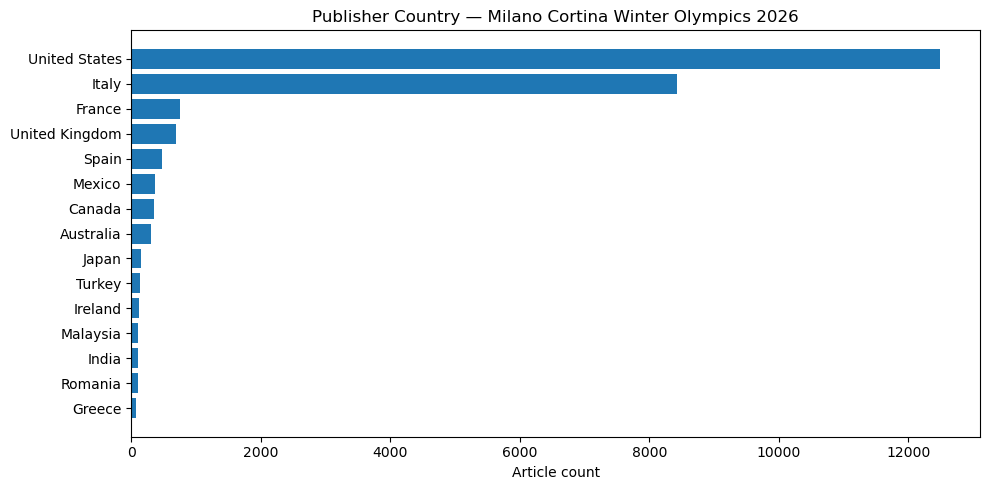

In [23]:
top_pub = pub_volume.head(15)

plt.figure(figsize=(10,5))
plt.barh(top_pub.index[::-1], top_pub.values[::-1])
plt.title("Publisher Country — Milano Cortina Winter Olympics 2026")
plt.xlabel("Article count")
plt.tight_layout()
plt.show()

In [24]:
# Export dataset
data_dir = Path("../data")
data_dir.mkdir(exist_ok=True)

output_path = data_dir / "gdelt_gkg_feb2026_relevance_ladder_lvl3_mapped.parquet"

df["day"] = pd.to_datetime(df["day"])
df.to_parquet(output_path, index=False)

output_path

PosixPath('../data/gdelt_gkg_feb2026_relevance_ladder_lvl3_mapped.parquet')